In [234]:
#библиотечки и т.д.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from matplotlib.pylab import norm
import scipy.stats as stats
from scipy.stats import norm, kstest

In [235]:
df = pd.read_csv('insurance.csv')
#датасет - информация о людях в страховой компании: 
#возраст, пол, индекс массы тела, курение, количество детей и стоимость страховки

In [236]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [237]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [238]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

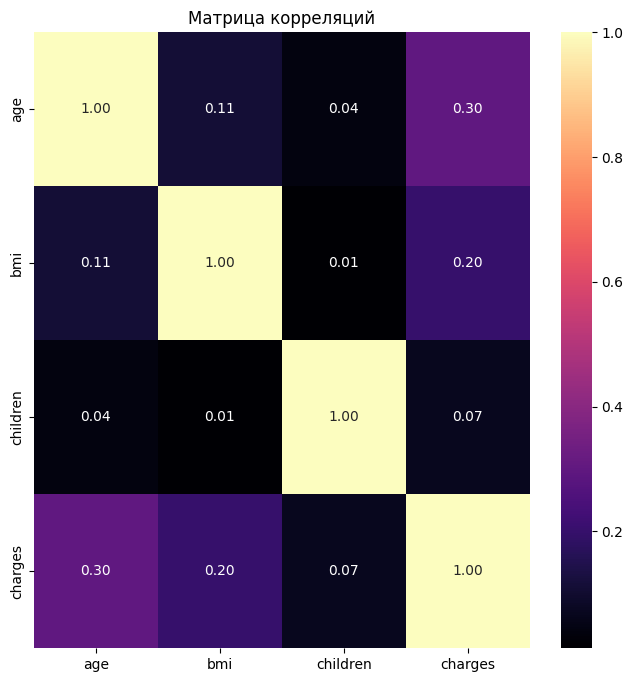

In [239]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.title("Матрица корреляций")
plt.show()

In [240]:
#кодирование категориальных признаков 
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df['sex'] = df['sex'].map({'female' : 1, 'male' : 0})
df['smoker'] = df['smoker'].map({'yes' : 1, 'no' : 0})
df['bmi_2'] = df['bmi'] ** 2
df['smoker_bmi_2'] = df['smoker'] * (df['bmi_2'])

In [241]:
df['is_obese'] = (df['bmi'] > 30).astype(int)
#df['smoker_bmi'] = df['smoker'] * df['is_obese']
df['obese_smoker'] = df['is_obese'] * df['smoker']
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_2,smoker_bmi_2,is_obese,obese_smoker
0,19,1,27.900,0,1,16884.92400,False,False,True,778.410000,778.41,0,0
1,18,0,33.770,1,0,1725.55230,False,True,False,1140.412900,0.00,1,0
2,28,0,33.000,3,0,4449.46200,False,True,False,1089.000000,0.00,1,0
3,33,0,22.705,0,0,21984.47061,True,False,False,515.517025,0.00,0,0
4,32,0,28.880,0,0,3866.85520,True,False,False,834.054400,0.00,0,0


<Axes: xlabel='age', ylabel='charges'>

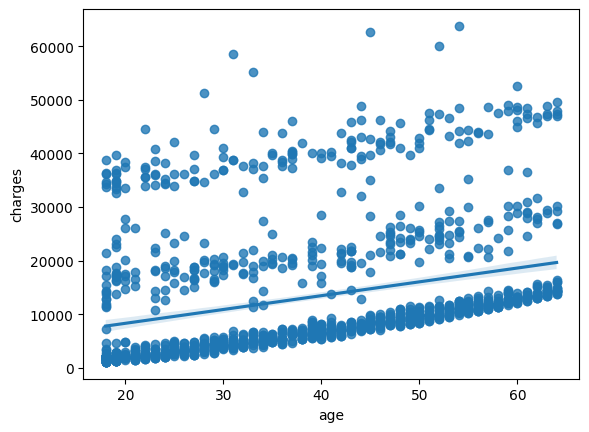

In [242]:
sns.regplot(x='age', y='charges', data=df)

<Axes: xlabel='bmi', ylabel='charges'>

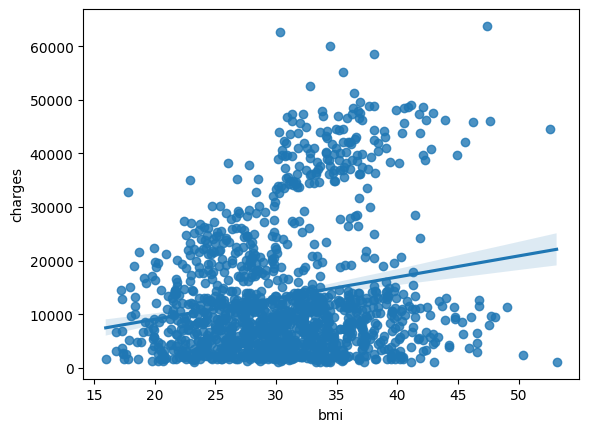

In [243]:
sns.regplot(x='bmi', y='charges', data=df)

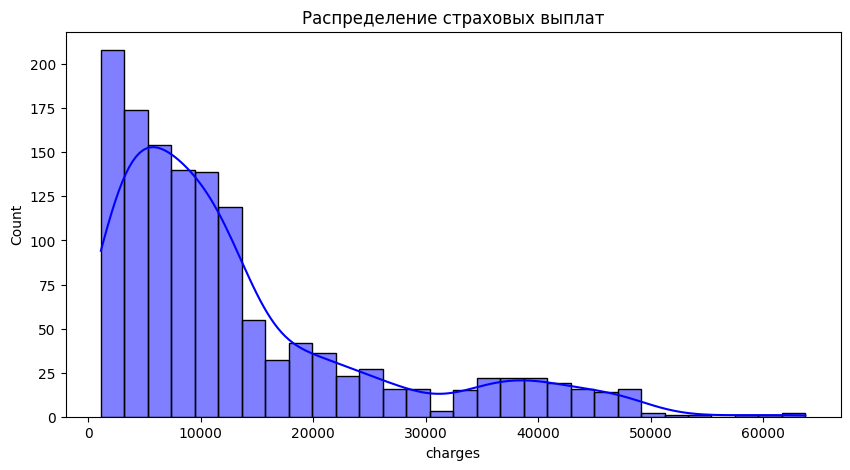

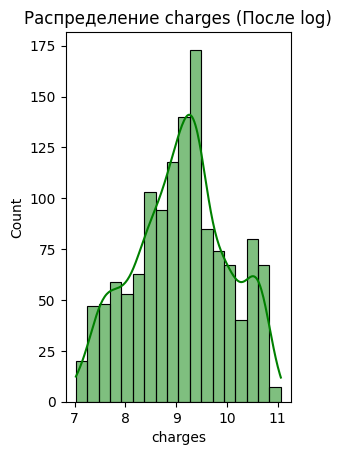

In [244]:
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Распределение страховых выплат')
plt.show()

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['charges']), kde=True, color='green')
plt.title('Распределение charges (После log)')

plt.show()

лучше взять по логарифму (намного ближе к нормальному распределению)

In [245]:
df['charges_log'] = np.log1p(df['charges'])
df['bmi_above_30'] = (df['bmi'] - 30).apply(lambda x: max(0, x))
#df['charges_log'] = df['charges']
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_2,smoker_bmi_2,is_obese,obese_smoker,charges_log,bmi_above_30
0,19,1,27.900,0,1,16884.92400,False,False,True,778.410000,778.41,0,0,9.734236,0.00
1,18,0,33.770,1,0,1725.55230,False,True,False,1140.412900,0.00,1,0,7.453882,3.77
2,28,0,33.000,3,0,4449.46200,False,True,False,1089.000000,0.00,1,0,8.400763,3.00
3,33,0,22.705,0,0,21984.47061,True,False,False,515.517025,0.00,0,0,9.998137,0.00
4,32,0,28.880,0,0,3866.85520,True,False,False,834.054400,0.00,0,0,8.260455,0.00


<Axes: xlabel='age', ylabel='charges_log'>

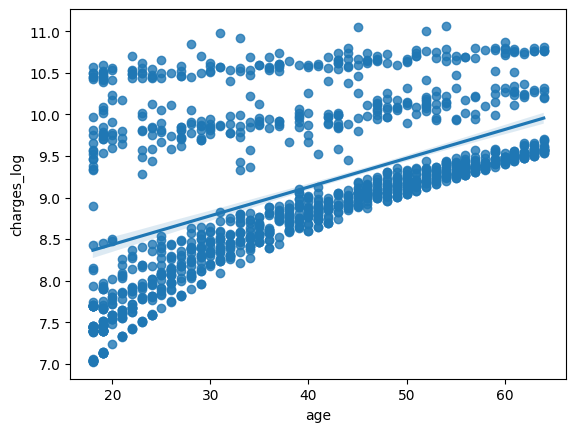

In [246]:
sns.regplot(x='age', y='charges_log', data=df)

In [247]:
def get_risk_group_numeric(row):
    if row['smoker'] == 0:
        return 'Некурящие (0)'
    elif row['smoker'] == 1 and row['bmi'] < 30:
        return 'Курящие, BMI < 30 (1)'
    else:
        return 'Курящие, BMI >= 30 (1)'
df['risk_group'] = df.apply(get_risk_group_numeric, axis=1)


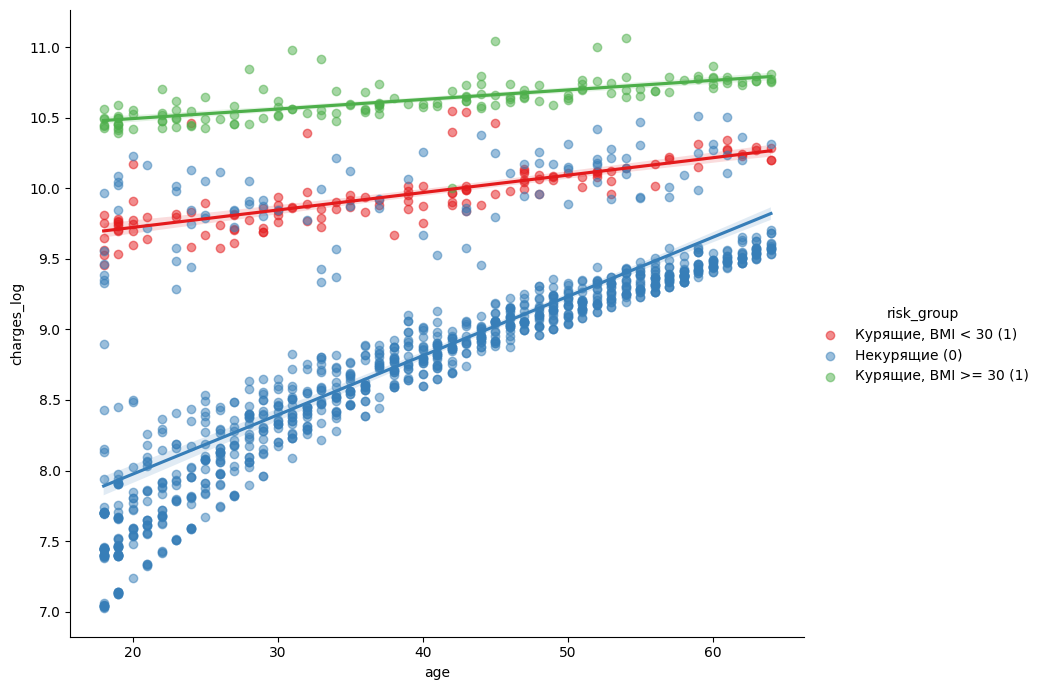

In [248]:
sns.lmplot(x='age', 
           y='charges_log', 
           hue='risk_group', 
           data=df, 
           palette='Set1',
           height=7, 
           aspect=1.2,
           scatter_kws={'alpha':0.5})

In [249]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_2,smoker_bmi_2,is_obese,obese_smoker,charges_log,bmi_above_30,risk_group
0,19,1,27.900,0,1,16884.92400,False,False,True,778.410000,778.41,0,0,9.734236,0.00,"Курящие, BMI < 30 (1)"
1,18,0,33.770,1,0,1725.55230,False,True,False,1140.412900,0.00,1,0,7.453882,3.77,Некурящие (0)
2,28,0,33.000,3,0,4449.46200,False,True,False,1089.000000,0.00,1,0,8.400763,3.00,Некурящие (0)
3,33,0,22.705,0,0,21984.47061,True,False,False,515.517025,0.00,0,0,9.998137,0.00,Некурящие (0)
4,32,0,28.880,0,0,3866.85520,True,False,False,834.054400,0.00,0,0,8.260455,0.00,Некурящие (0)


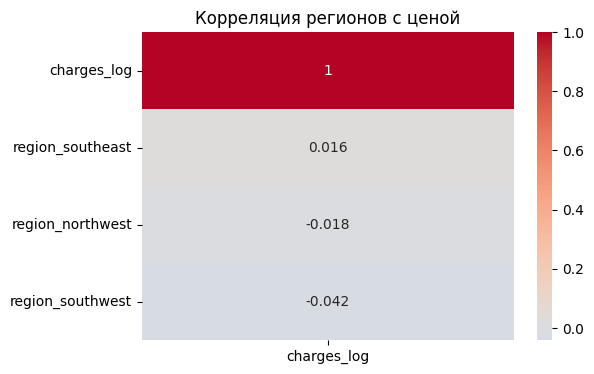

In [250]:
region_cols = [col for col in df.columns if 'region' in col] + ['charges_log']
region_corr = df[region_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(region_corr[['charges_log']].sort_values(by='charges_log', ascending=False), 
            annot=True, cmap='coolwarm', center=0)
plt.title("Корреляция регионов с ценой")
plt.show()

In [251]:
#регионы лучше выбросить, т.к. корелляция минимальна
df = df.drop(columns=[col for col in df.columns if 'region' in col])
#уже есть charges_log, поэтому можно удалить charges
df = df.drop(columns=['charges', 'risk_group'], errors='ignore')
df.head()

,age,sex,bmi,children,smoker,bmi_2,smoker_bmi_2,is_obese,obese_smoker,charges_log,bmi_above_30
0,19,1,27.900,0,1,778.410000,778.41,0,0,9.734236,0.00
1,18,0,33.770,1,0,1140.412900,0.00,1,0,7.453882,3.77
2,28,0,33.000,3,0,1089.000000,0.00,1,0,8.400763,3.00
3,33,0,22.705,0,0,515.517025,0.00,0,0,9.998137,0.00
4,32,0,28.880,0,0,834.054400,0.00,0,0,8.260455,0.00


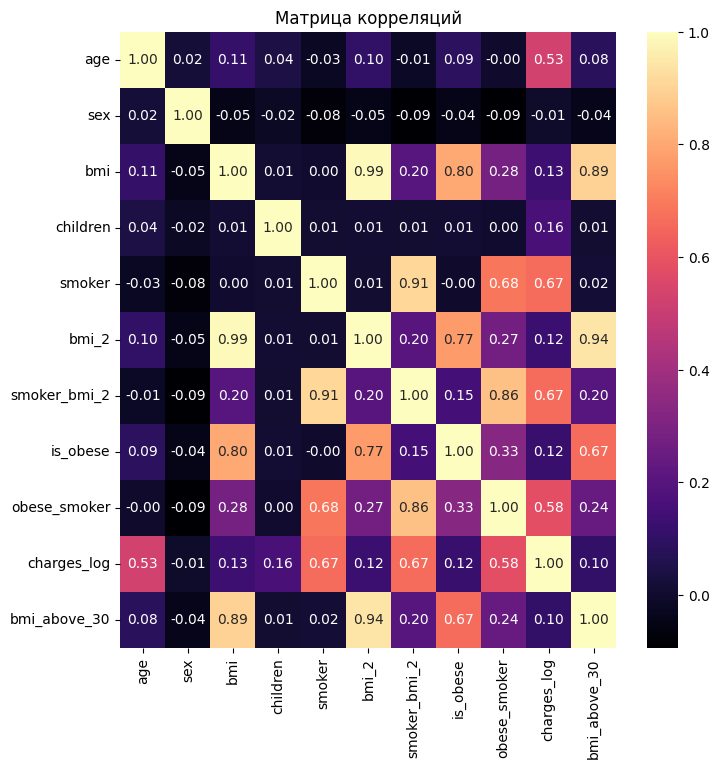

In [252]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.title("Матрица корреляций")
plt.show()

In [253]:
X = df.drop(columns=['charges_log'])
y = df['charges_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1070, 10) (268, 10) (1070,) (268,)


In [254]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures


linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  0.8199799367360088
R2_score (train):  0.8339351385566978
R2_score (test):  0.855933325374582
RMSE:  0.3598538501936542
MAPE:  0.02218996717838503


In [255]:
y_train.ravel().shape

/var/folders/zw/j9h9wg0j77z0xcmnlr_dj9080000gn/T/ipykernel_17438/1078338228.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train.ravel().shape


(1070,)

/var/folders/zw/j9h9wg0j77z0xcmnlr_dj9080000gn/T/ipykernel_17438/2901282516.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residuals = (y_train.ravel() - y_pred_linear_train.ravel())


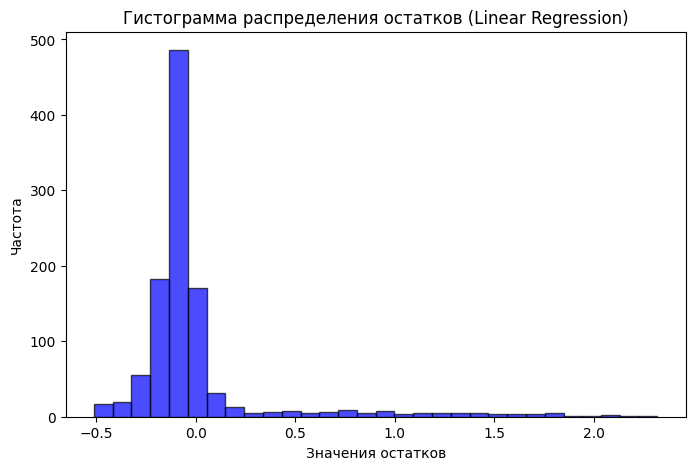

Статистика Колмогорова-Смирнова: 0.3193, P-значение: 1.4813e-97
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


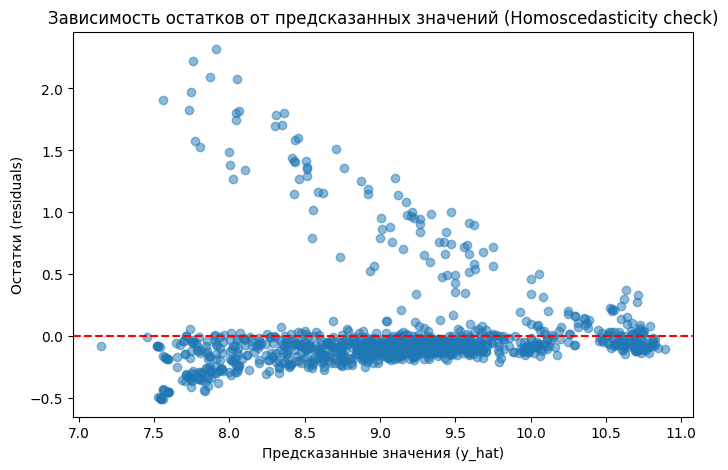

In [256]:
residuals = (y_train.ravel() - y_pred_linear_train.ravel())

def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, 'norm', args=(residuals_mean, residuals_std))
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear_train)

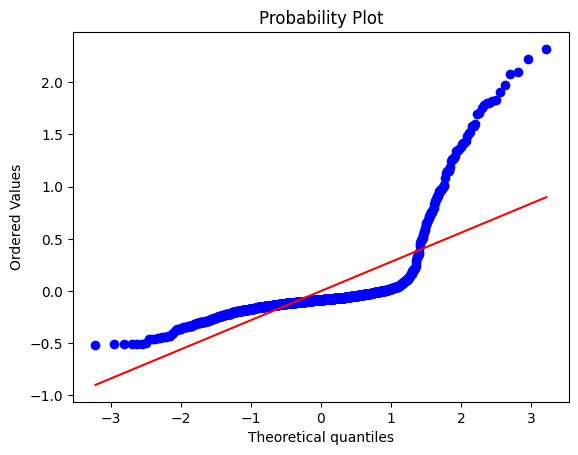

In [257]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

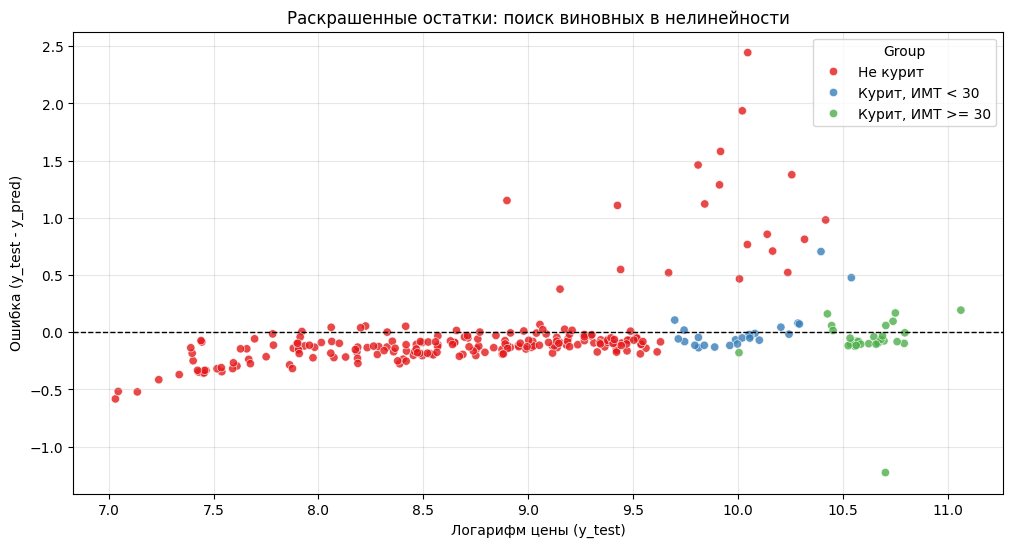

In [258]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Создаем чистый DataFrame из тестовых данных
# reset_index(drop=True) критически важен, чтобы индексы совпали с y_pred
plot_df = X_test.reset_index(drop=True)
plot_df['Residuals'] = y_test.values - y_pred_linear_test.flatten()
plot_df['Actual'] = y_test.values

# 2. Создаем понятные метки для легенды
plot_df['Group'] = 'Other'
plot_df.loc[(plot_df['smoker'] == 1) & (plot_df['bmi'] < 30), 'Group'] = 'Курит, ИМТ < 30'
plot_df.loc[(plot_df['smoker'] == 1) & (plot_df['bmi'] >= 30), 'Group'] = 'Курит, ИМТ >= 30'
plot_df.loc[(plot_df['smoker'] == 0), 'Group'] = 'Не курит'

# 3. Строим график
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df, x='Actual', y='Residuals', hue='Group', palette='Set1', alpha=0.8)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Раскрашенные остатки: поиск виновных в нелинейности")
plt.xlabel("Логарифм цены (y_test)")
plt.ylabel("Ошибка (y_test - y_pred)")
plt.grid(alpha=0.3)
plt.show()

AttributeError: 'int' object has no attribute 'capitalize'

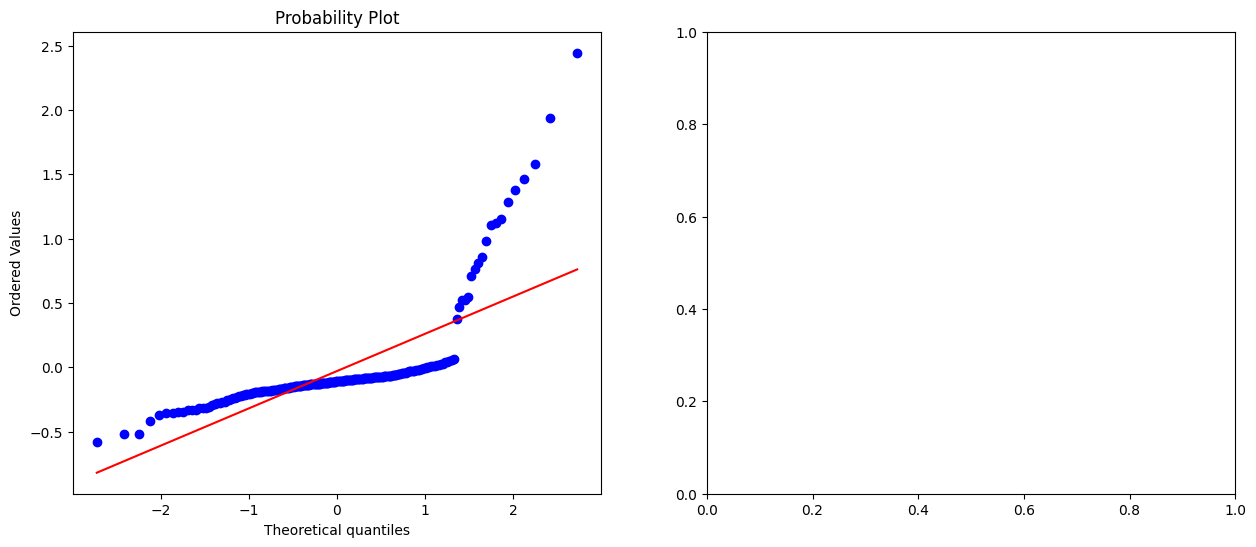

In [259]:
import scipy.stats as stats

# Группируем остатки по курению
groups = plot_df.groupby('smoker')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, group) in enumerate(groups):
    ax = axes[i]
    # Строим QQ-plot для каждой группы отдельно
    stats.probplot(group['Residuals'], dist="norm", plot=ax)
    ax.set_title(f"QQ-plot для группы: {name.capitalize()}")

plt.tight_layout()
plt.show()

выводы? (kinda...)
датасет не особо подходит для нашего метода. по статистике остатков и графикам видно, что есть сложные зависимости, плохо описываемые лин. регрессией. когда-нибудь попозже допилю эту штуку на более подходящих данных, а пока чет надоело и не хочется:/ тем более я и так весь в долгах... (кто-то это читает? даже интересно))))